In [ ]:
# Install required libraries (run once)
# !pip install numpy pandas matplotlib seaborn scikit-learn torch torchvision xgboost

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, silhouette_score
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

import xgboost as xgb

import torch
import torchvision
import torchvision.transforms as transforms

In [ ]:
# Download dataset
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Convert to numpy
X_train = train_dataset.data.numpy()
y_train = train_dataset.targets.numpy()

X_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten images (28x28 → 784)
X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.2MB/s]


Train shape: (60000, 784)
Test shape: (10000, 784)


In [ ]:
# Use smaller subset (as allowed in assignment)
subset_size = 10000

X_train, _, y_train, _ = train_test_split(
    X_train, y_train, train_size=subset_size, stratify=y_train, random_state=42
)

In [ ]:
# Logistic Regression baseline
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))

Baseline Accuracy: 0.8258


In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8476


In [ ]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)
print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))

AdaBoost Accuracy: 0.5675


In [ ]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:59:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8688


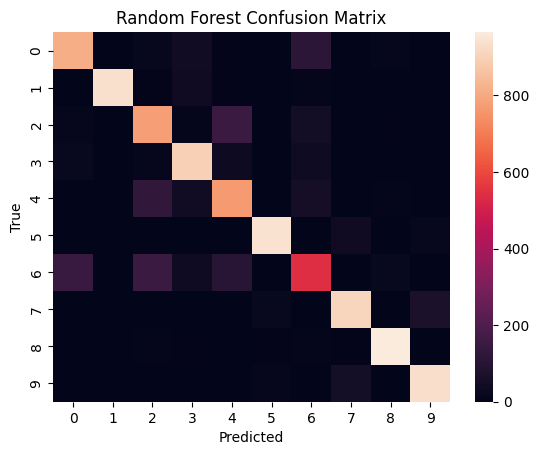

In [ ]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_confusion(y_test, rf_pred, "Random Forest Confusion Matrix")

In [ ]:
kmeans_10 = KMeans(n_clusters=10, random_state=42)
clusters_10 = kmeans_10.fit_predict(X_train)

kmeans_30 = KMeans(n_clusters=30, random_state=42)
clusters_30 = kmeans_30.fit_predict(X_train)

In [ ]:
dbscan = DBSCAN(eps=3, min_samples=10)
db_clusters = dbscan.fit_predict(X_train)

In [ ]:
score_10 = silhouette_score(X_train, clusters_10)
score_30 = silhouette_score(X_train, clusters_30)

print("Silhouette (k=10):", score_10)
print("Silhouette (k=30):", score_30)

Silhouette (k=10): 0.1421539568697111
Silhouette (k=30): 0.09485475264314916


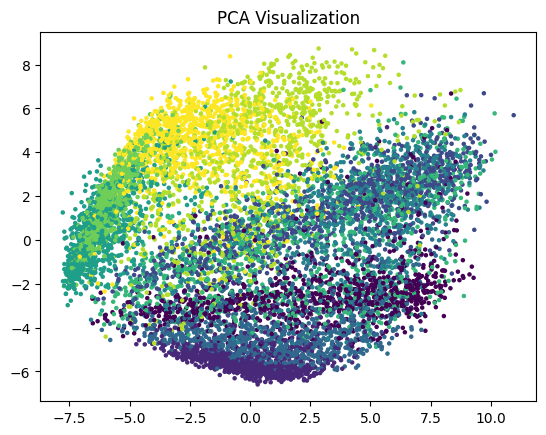

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, s=5)
plt.title("PCA Visualization")
plt.show()

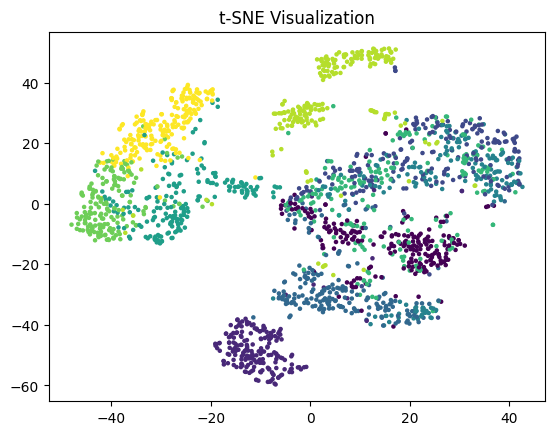

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_train[:2000])  # smaller subset

plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train[:2000], s=5)
plt.title("t-SNE Visualization")
plt.show()

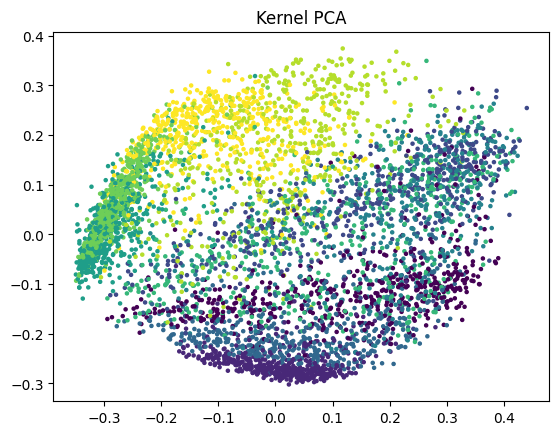

In [ ]:
kpca = KernelPCA(n_components=2, kernel='rbf')
X_kpca = kpca.fit_transform(X_train[:5000])

plt.figure()
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_train[:5000], s=5)
plt.title("Kernel PCA")
plt.show()

In [ ]:
import torch.nn as nn
from torchvision.models import resnet18

# Load pretrained model
model = resnet18(pretrained=True)
model.fc = nn.Identity()  # remove classifier
model.eval()

# Transform to match ResNet input
transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])
def extract_features(dataset, max_samples=2000):
    features = []
    labels = []

    for i in range(max_samples):
        img, label = dataset[i]

        # Fix: convert to PIL
        img = to_pil_image(img)

        img = transform_resnet(img).unsqueeze(0)

        with torch.no_grad():
            feat = model(img).cpu().numpy().flatten()

        features.append(feat)
        labels.append(label)

    return np.array(features), np.array(labels)

X_cnn, y_cnn = extract_features(train_dataset)

In [ ]:
print(X_cnn.shape)

(2000, 512)


In [ ]:
kmeans_cnn = KMeans(n_clusters=10, random_state=42)
cnn_clusters = kmeans_cnn.fit_predict(X_cnn)

print("Silhouette (CNN features):", silhouette_score(X_cnn, cnn_clusters))

Silhouette (CNN features): 0.10691975
